In [1]:
import matplotlib.pyplot as plt
import scienceplots
import pandas as pd
import numpy as np
plt.style.use(['science', 'notebook', 'grid'])

def extract(path, bool_term=False):
    with open(path, 'r') as file:
        content = file.read()
    lines = content.strip().split('\n')
    array_line = lines[-1]
    data = eval(array_line)
    if bool_term == True:
        return [item for item in data if item[1] == True], [i for i, item in enumerate(data) if item[1] == True]
    else: 
        return data
    

def grid_maker(qm, qd, bool_term=False, true_indices=None):
    X, Y = np.meshgrid(qm, qd)
    X_flat = X.flatten()
    Y_flat = Y.flatten()
    grid_obs = list(zip(X_flat, Y_flat))

    if bool_term == True:
        grid_values = [[X_flat[i], Y_flat[i]] for i in true_indices]
    else: 
        grid_values = [X,Y]
    return np.array(grid_values)
 
def contour_maker(grid_values, MLE_data, bool_term=False,true_indices=None,ax=None,levels= [0, 2.3, 6.18, 11.83, 19.33, 28.7]):

    
    if bool_term == True:
        X_vals = grid_values[:, 0]
        Y_vals = grid_values[:, 1]
        Z_vals = [item[0] for item in MLE_data]
        if ax is not None:
            contour = ax.tricontourf(X_vals, Y_vals, np.array(Z_vals) - min(Z_vals), levels=levels, cmap='YlGnBu')
        else:
            contour = plt.tricontourf(X_vals, Y_vals, np.array(Z_vals) - min(Z_vals), levels=levels, cmap='YlGnBu')
    else:
        X_vals = grid_values[0]
        Y_vals = grid_values[1]
        Z_vals = np.array(MLE_data).reshape(len(Y_vals), len(X_vals))
        if ax is not None:
            contour = ax.contourf(X_vals, Y_vals, np.array(Z_vals) - np.min(Z_vals), levels=levels, cmap='YlGnBu')
        else:
            contour = plt.contourf(X_vals, Y_vals, np.array(Z_vals) - np.min(Z_vals), levels=levels, cmap='YlGnBu')

    return contour
        





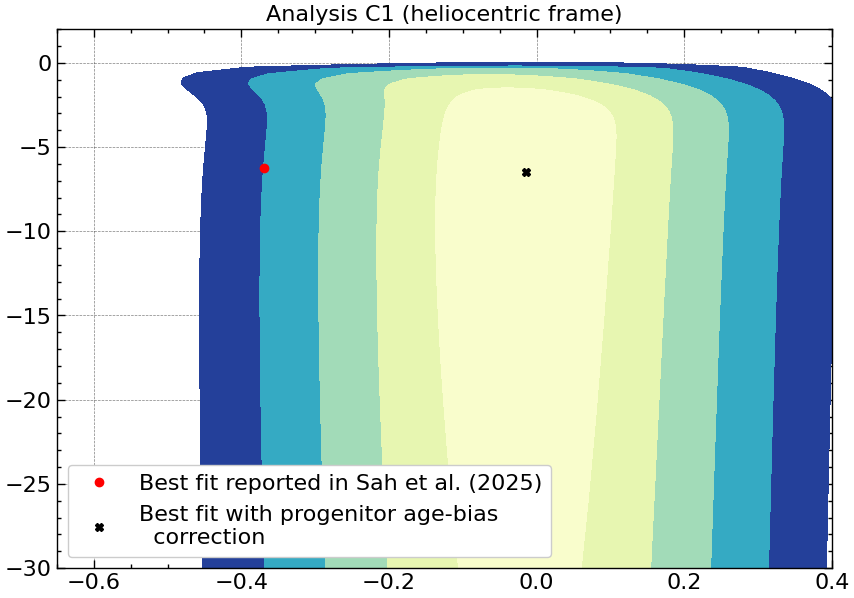

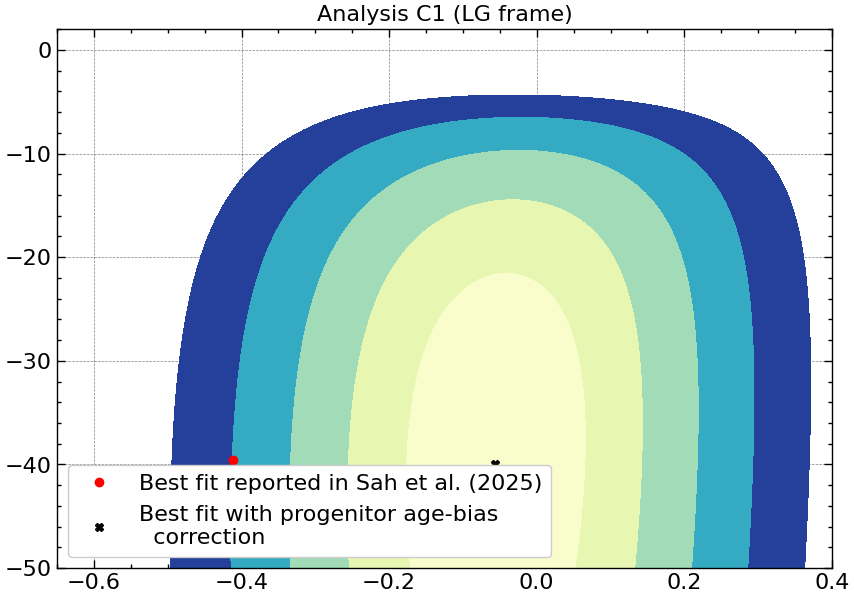

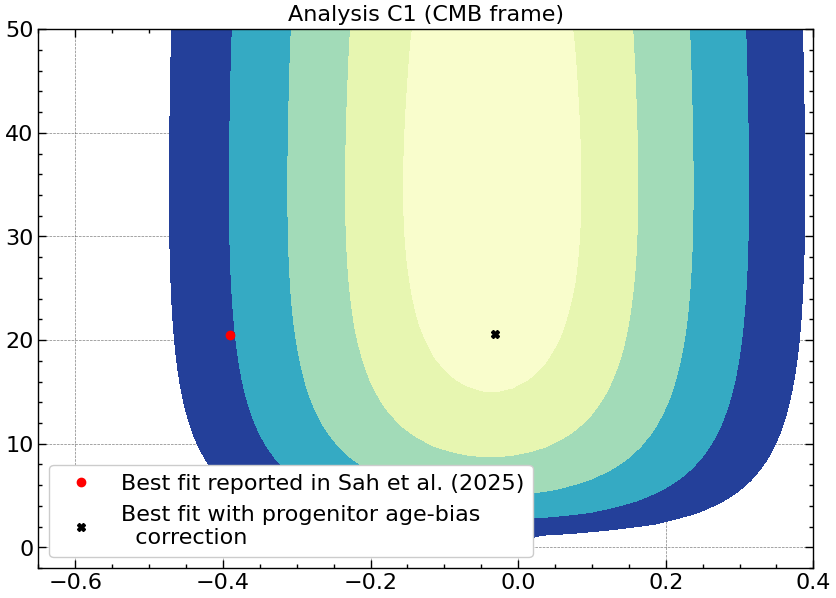

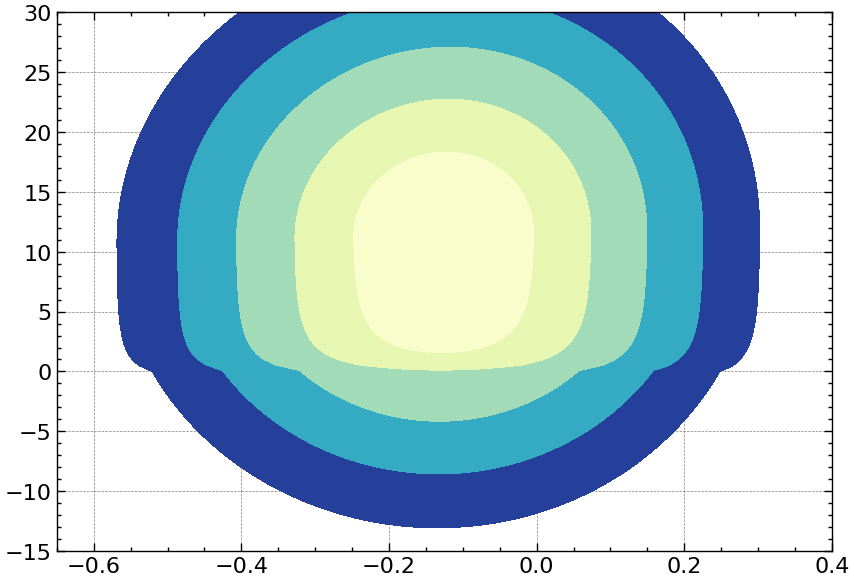

In [28]:
plt.figure(figsize=(10,7))
qm_hel_C1  = np.linspace(-0.65,0.4,100)
qd_hel_C1  = np.linspace(-30,2,100) 
MLE_hel_C1  = extract('AGE_BIAS_QM_QD_7_Code2.txt')


contour_maker(grid_maker(qm_hel_C1, qd_hel_C1), MLE_hel_C1)
qm_previous_hel_C1  = -0.369
qd_previous_hel_C1  = -6.27
qm_new_hel_C1= -1.388e-02
qd_new_hel_C1= -6.499e+00

plt.plot(qm_previous_hel_C1, qd_previous_hel_C1, 'ro', label='Best fit reported in Sah et al. (2025)')
plt.plot(qm_new_hel_C1, qd_new_hel_C1, 'kX', label='Best fit with progenitor age-bias \n  correction')
plt.legend(loc  = 'lower left')
plt.title('Analysis C1 (heliocentric frame)')



plt.figure(figsize=(10,7))



qm_LG_C1 = np.linspace(-0.65, 0.4, 130)
qd_LG_C1 = np.linspace(-50, 2.0, 130)
qm_previous_LG_C1  = -0.411
qd_previous_LG_C1  = -39.6
qm_new_LG_C1= -0.056
qd_new_LG_C1= -39.92
MLE_LG_C1 = extract('AGE_BIAS_QM_QD_9_results_v2.txt',bool_term=True)
LG_indices_C1 = MLE_LG_C1[1]
contour_maker(grid_maker(qm_LG_C1, qd_LG_C1,bool_term =True,true_indices=LG_indices_C1), MLE_LG_C1[0], bool_term=True)
plt.plot(qm_previous_LG_C1, qd_previous_LG_C1, 'ro', label='Best fit reported in Sah et al. (2025)')
plt.plot(qm_new_LG_C1, qd_new_LG_C1, 'kX', label='Best fit with progenitor age-bias \n  correction')
plt.title('Analysis C1 (LG frame)')
plt.legend(loc  = 'lower left')



plt.figure(figsize=(10,7))



qm_CMB_C1 = np.linspace(-0.65, 0.4,50)
qd_CMB_C1 = np.linspace(50, -2.0, 50)
qm_previous_CMB_C1  = -0.39
qd_previous_CMB_C1  = 20.5
qm_new_CMB_C1= -0.032
qd_new_CMB_C1= 20.61
MLE_CMB_C1 = extract('AGE_BIAS_QM_QD_8_Code2.txt',bool_term=False)
contour_maker(grid_maker(qm_CMB_C1, qd_CMB_C1), MLE_CMB_C1)
plt.plot(qm_previous_CMB_C1, qd_previous_CMB_C1, 'ro', label='Best fit reported in Sah et al. (2025)')
plt.plot(qm_new_CMB_C1, qd_new_CMB_C1, 'kX', label='Best fit with progenitor age-bias \n  correction')
plt.title('Analysis C1 (CMB frame)')
plt.legend(loc  = 'lower left')
plt.figure(figsize=(10,7))


qm_HD_C1 = np.linspace(-0.65, 0.4,100)
qd_HD_C1  = np.linspace(-15,30,100)
MLE_HD_C1 = extract('AGE_BIAS_QM_QD_0_Code2.txt',bool_term=False)

contour_maker(grid_maker(qm_HD_C1, qd_HD_C1), MLE_HD_C1)



qm_previous_HD_C1  = -0.49
qd_previous_HD_C1  = 11.4
qm_new_HD_C1= -0.12
qd_new_HD_C1= 11.4

In [3]:
qm_old_hel_C2, qd_old_hel_C2 = 0.01, -31.8
qm_new_hel_C2, qd_new_hel_C2 = 3.540e-01, -32.1

qm_old_cmb_C2, qd_old_cmb_C2 = -0.03, 21.1
qm_new_cmb_C2, qd_new_cmb_C2 = 3.204e-01, 2.127e+01
qm_old_lg_C2, qd_old_lg_C2 = -0.0038, -61.4
qm_new_lg_C2, qd_new_lg_C2 = 0.308, -61.93

qm_old_HD_C2 , qd_old_HD_C2 = -1.554e-01 ,1.131e+01 
qm_new_HD_C2 , qd_new_HD_C2 = 2.171e-01 ,1.136e+01 
df_hel_C2 = pd.read_csv('qm_qd_hel_age_bias_v2/combined_results_v3.csv', header=None)
df_cmb_C2 = pd.read_csv('qm_qd_CMB_age_bias_v2/combined_results.txt', header=None)
df_lg_C2 = pd.read_csv('qm_qd_LG_age_bias/combined_results.txt', header=None)
df_HD_C2 = pd.read_csv('qm_qd_HD_age_bias/combined_results.txt', header=None)

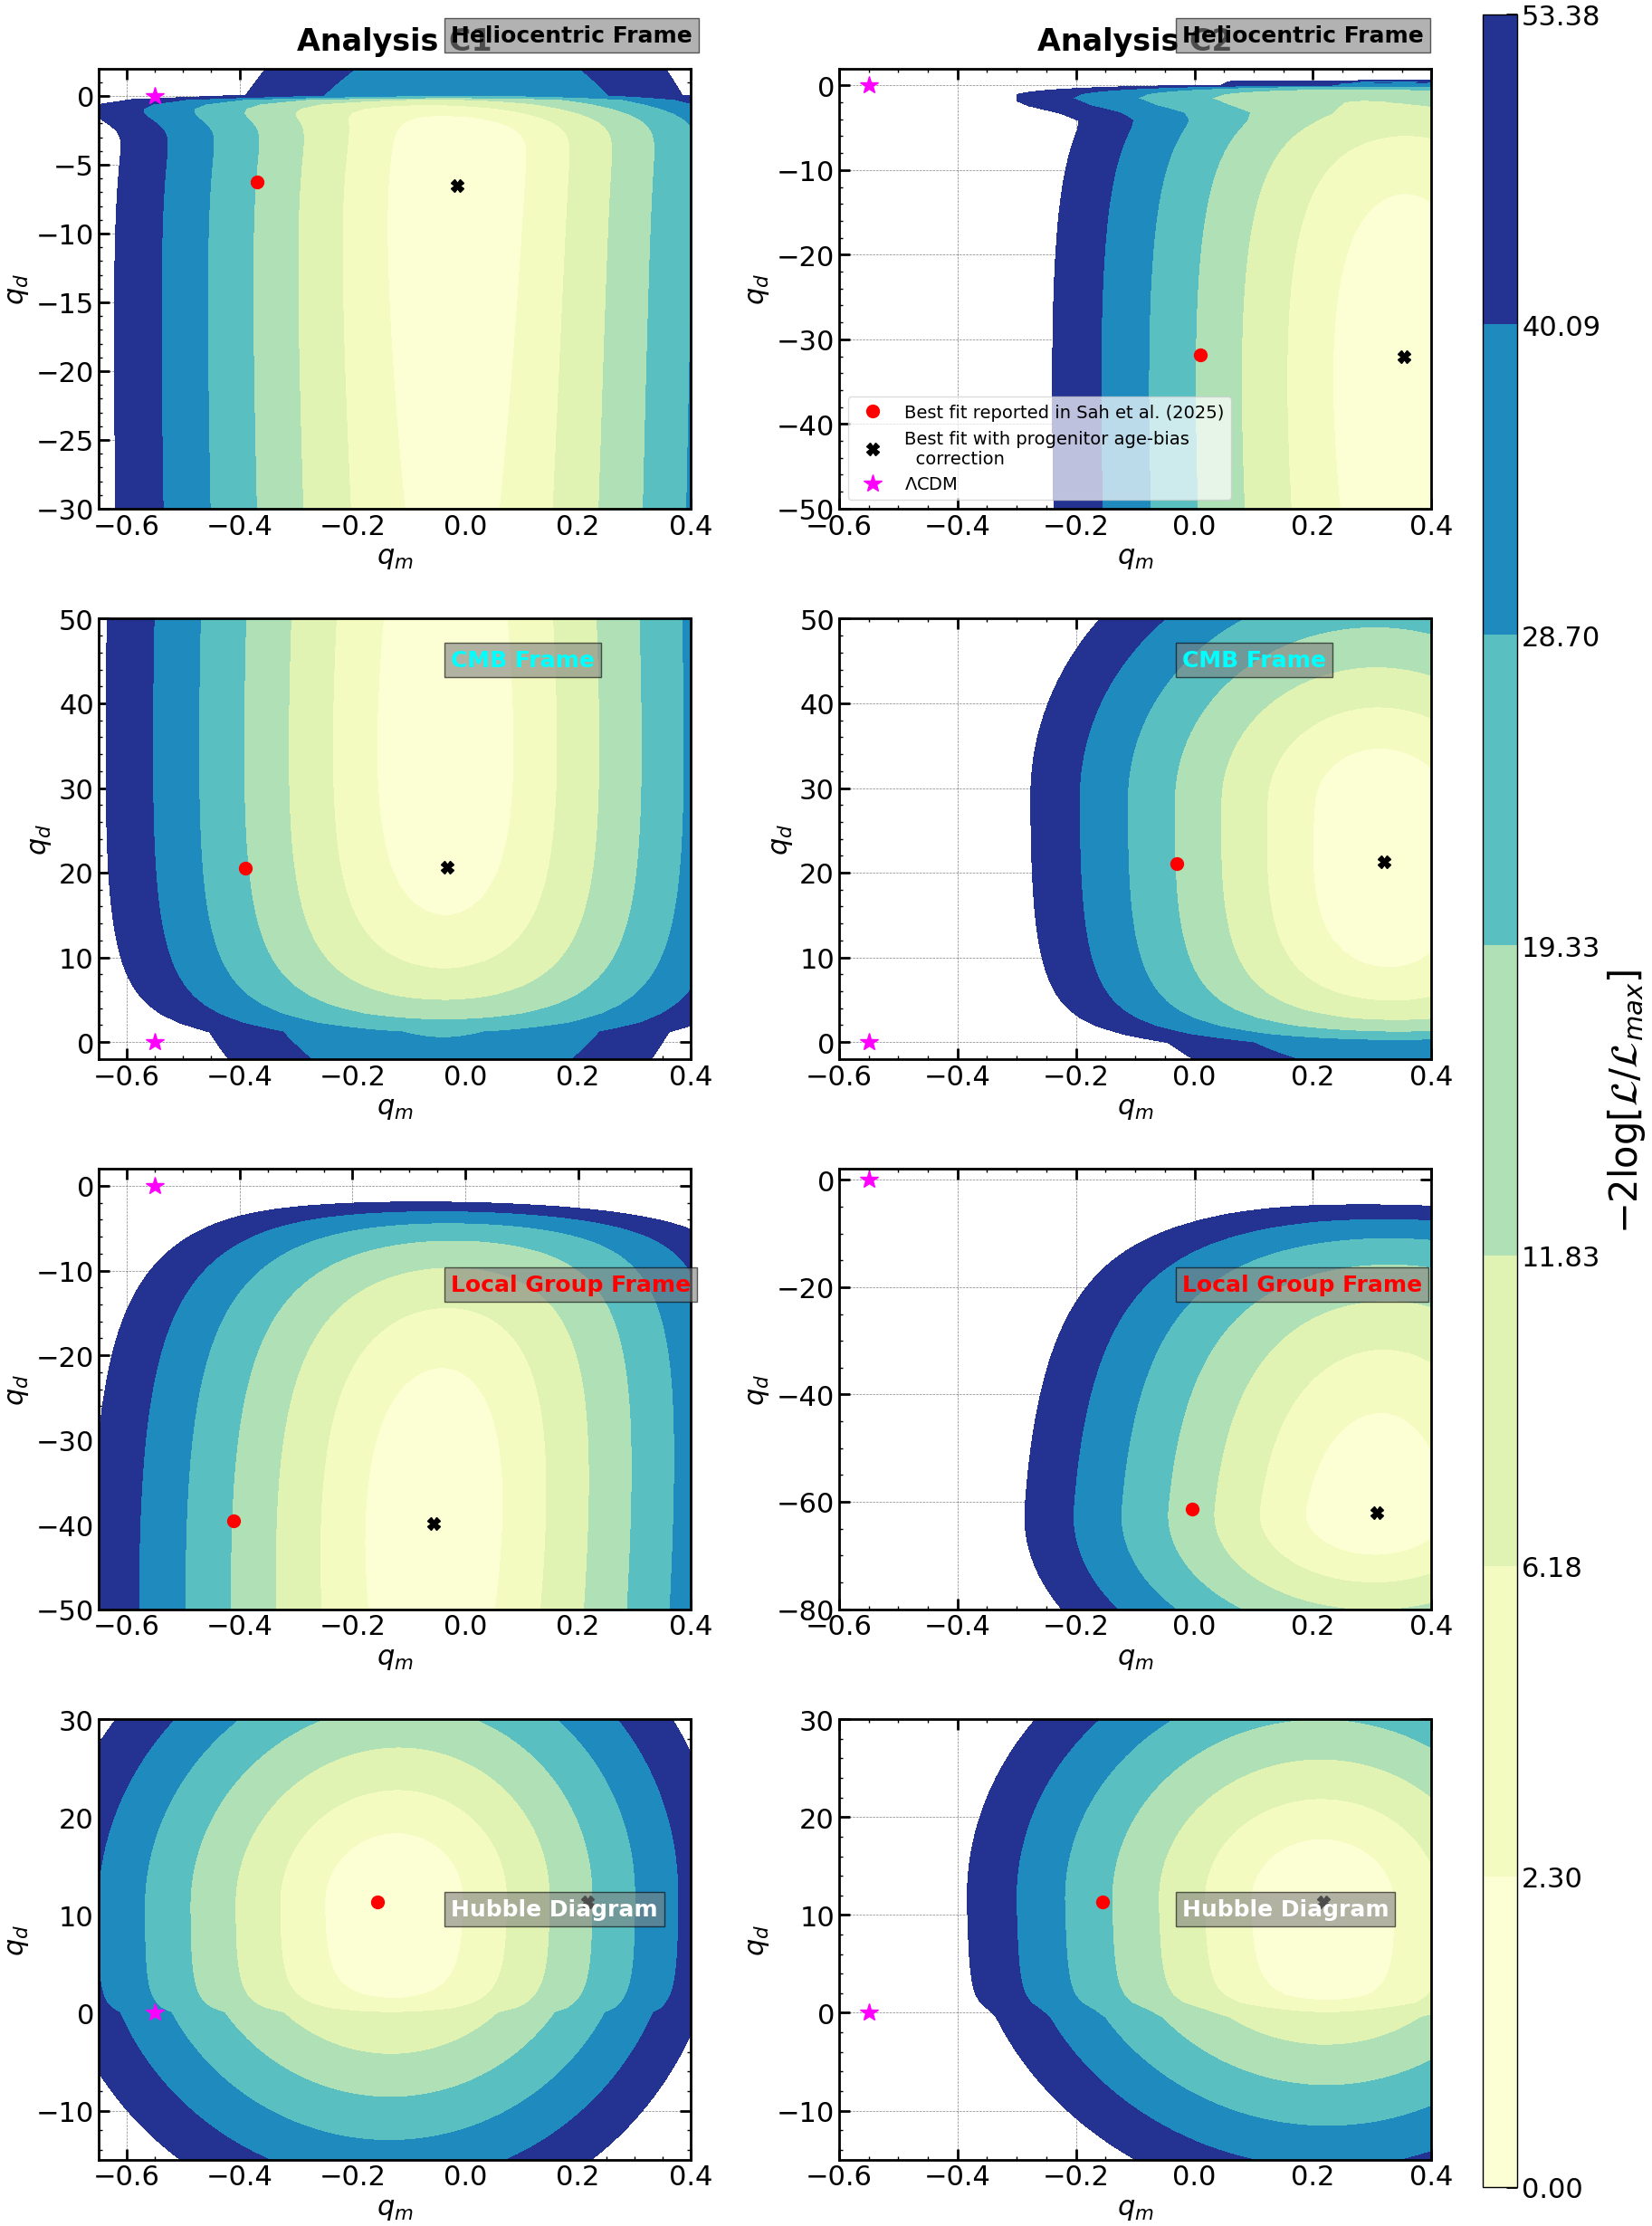

In [ ]:
fig, ax = plt.subplots(4, 2, figsize=(19,30))
ms = 10

levels = [0, 2.3, 6.18, 11.83, 19.33, 28.7,40.09,53.38]
##plotting for analysis C1
contour_maker(grid_maker(qm_hel_C1, qd_hel_C1), MLE_hel_C1,ax=ax[0,0],levels=levels)
contour_maker(grid_maker(qm_CMB_C1, qd_CMB_C1), MLE_CMB_C1,ax=ax[1,0],levels=levels)
contour_maker(grid_maker(qm_LG_C1, qd_LG_C1,bool_term =True,true_indices=LG_indices_C1), MLE_LG_C1[0], bool_term=True,ax=ax[2,0],levels=levels)
contour_maker(grid_maker(qm_HD_C1, qd_HD_C1), MLE_HD_C1,ax=ax[3,0],levels=levels)
ax[0,0].plot(qm_previous_hel_C1, qd_previous_hel_C1, 'ro', ms=ms, label='Best fit reported in Sah et al. (2025)')
ax[0,0].plot(qm_new_hel_C1, qd_new_hel_C1, 'kX', ms=ms, label='Best fit with progenitor age-bias \n  correction')

ax[1,0].plot(qm_previous_CMB_C1, qd_previous_CMB_C1, 'ro', ms=ms, label='Best fit reported in Sah et al. (2025)')
ax[1,0].plot(qm_new_CMB_C1, qd_new_CMB_C1, 'kX', ms=ms, label='Best fit with progenitor age-bias \n  correction')

ax[2,0].plot(qm_previous_LG_C1, qd_previous_LG_C1, 'ro', ms=ms, label='Best fit reported in Sah et al. (2025)')
ax[2,0].plot(qm_new_LG_C1, qd_new_LG_C1, 'kX', ms=ms, label='Best fit with progenitor age-bias \n  correction')

##plotting for analysis C2




# Extract data for C2 analysis
qm_hel_C2 = df_hel_C2[1].values
qd_hel_C2 = df_hel_C2[2].values
MLE_hel_C2 = df_hel_C2[3].values - np.min(df_hel_C2[3].values)

qm_CMB_C2 = df_cmb_C2[1].values
qd_CMB_C2 = df_cmb_C2[2].values
MLE_CMB_C2 = df_cmb_C2[3].values - np.min(df_cmb_C2[3].values)

qm_LG_C2 = df_lg_C2[1].values
qd_LG_C2 = df_lg_C2[2].values
MLE_LG_C2 = df_lg_C2[3].values - np.min(df_lg_C2[3].values)

# Plot C2 heliocentric frame
ax[0,1].tricontourf(qm_hel_C2, qd_hel_C2, MLE_hel_C2, 
                     levels=levels, cmap='YlGnBu')
ax[0,1].plot(qm_old_hel_C2, qd_old_hel_C2, 'ro',ms=ms, label='Best fit reported in Sah et al. (2025)')
ax[0,1].plot(qm_new_hel_C2, qd_new_hel_C2, 'kX',ms=ms, label='Best fit with progenitor age-bias \n  correction')

# Plot C2 CMB frame
ax[1,1].tricontourf(qm_CMB_C2, qd_CMB_C2, MLE_CMB_C2, 
                     levels=levels, cmap='YlGnBu')
ax[1,1].plot(qm_old_cmb_C2, qd_old_cmb_C2, 'ro',ms=ms, label='Best fit reported in Sah et al. (2025)')
ax[1,1].plot(qm_new_cmb_C2, qd_new_cmb_C2, 'kX',ms = ms, label='Best fit with progenitor age-bias \n  correction')

# Plot C2 Local Group frame
contour_plot= ax[2,1].tricontourf(qm_LG_C2, qd_LG_C2, MLE_LG_C2, 
                     levels=levels, cmap='YlGnBu')
ax[2,1].plot(qm_old_lg_C2, qd_old_lg_C2, 'ro', label='Best fit reported in Sah et al. (2025)')
ax[2,1].plot(qm_new_lg_C2, qd_new_lg_C2, 'kX', label='Best fit with progenitor age-bias \n  correction')


ax[3,1].tricontourf(df_HD_C2[1].values, df_HD_C2[2].values, df_HD_C2[3].values - np.min(df_HD_C2[3].values), 
                     levels=levels, cmap='YlGnBu')





for i in range(4):
    ax[i,1].set_xlim(-0.6, 0.4)

for i in range(4):
    for j in range(2):
        ax[i,j].plot(-0.55, 0, '*',color='magenta', ms='15', label='$\Lambda$CDM')

ax[0,1].legend(frameon=True, framealpha=0.7)

for i in range(0, 4):
    for j in range(0, 2):
        
            ax[i, j].set_ylim(ax[i, j].get_ylim())  # To ensure consistent axis limits
            ax[i, j].tick_params(labelsize=22, width=2, length=8.5, axis='both', which='major')
            for axis in ['left', 'bottom', 'top', 'right']:
                ax[i, j].spines[axis].set_linewidth(2)
fig.text(0.386,0.39,'CMB Frame',size=18,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5},color='cyan',weight='bold')
fig.text(0.805,0.39,'CMB Frame',size=18,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5},color='cyan',weight='bold')

fig.text(0.33,0.66,'Heliocentric Frame',size=18 ,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5,},weight='bold')
fig.text(0.755,0.66,'Heliocentric Frame',size=18,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5,},weight='bold')

fig.text(0.34,0.12,'Local Group Frame',size=18,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5},color='red',weight='bold')
fig.text(0.756,0.12,'Local Group Frame',size=18,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5},color='red',weight='bold')

cax = fig.add_axes([0.93, 0.1, 0.02, 0.8])  # Adjust the position and size as needed
cbar = fig.colorbar(contour_plot, cax=cax)
cbar.set_label('$-2 \log [\mathcal{L}/\mathcal{L}_{max}]$', fontsize=30)
for axis in 'left', 'bottom','top','right':
           cbar.ax.spines[axis].set_linewidth(2)
cbar.ax.tick_params(labelsize=22,width=2,length=8.5,axis='both',which='major')
plt.savefig('Age_bias_corrected_conoturs.pdf')
plt.show()



NameError: name 'x_C1_CMB' is not defined

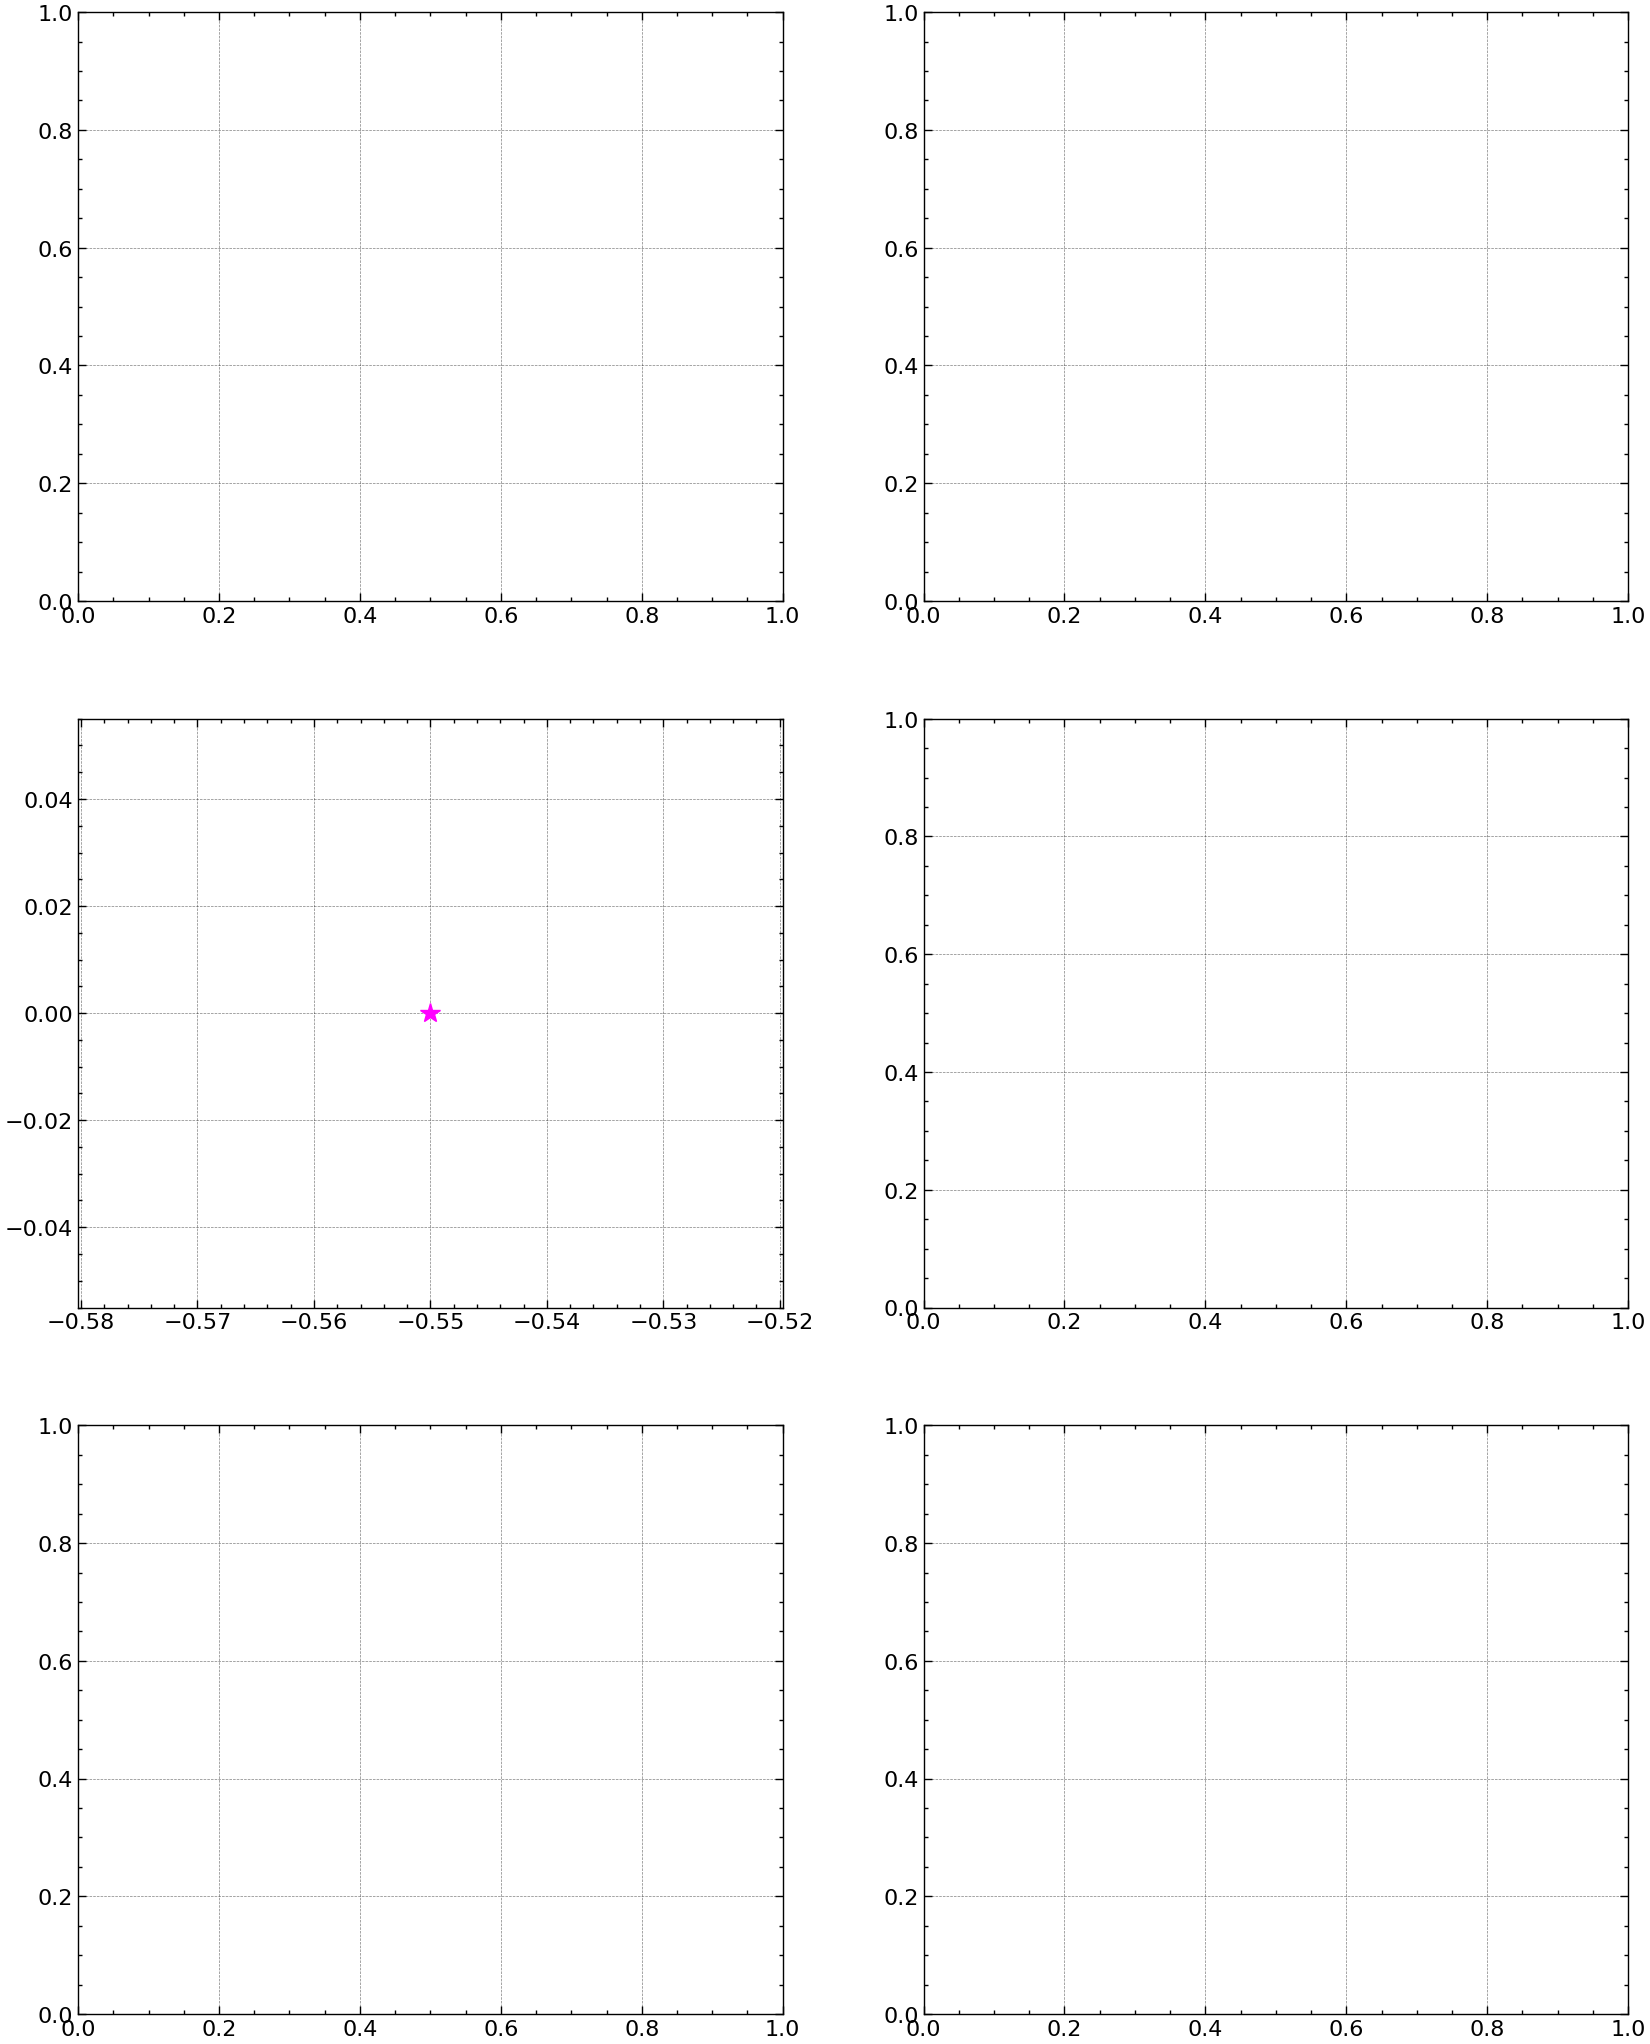

In [5]:
fig, ax = plt.subplots(3, 2, figsize=(20,26))
#fig.tight_layout()

ax[1,0].plot(-0.55, 0, '*',color='magenta', ms='15', label='$\Lambda$CDM')
contour_plot= ax[1,0].contourf(x_C1_CMB, y_C1_CMB, np.array(MLE_C1_CMB)+1519.33, cmap='YlGnBu',levels=[0.01,2.295749,6.18,11.829,19.33,28.7,40.09,53.38])
#plt.contourf(x, y, np.array(MLE_CMB)+1519.33, cmap='YlGnBu',levels=5)
ax[1,0].plot(qm_new_CMB, qd_new_CMB,'.',ms='10',label='Best-fit',color='purple')

#leg=plt.legend(frameon=True,fontsize=20)
#cbar =plt.colorbar(label='$-2 log [\mathcal{L}/\mathcal{L}_{max}]$')
#cbar.ax.yaxis.label.set_fontsize(18)
ax[1,0].set_xlabel('$q_\mathrm{m}$',fontsize=21)
ax[1,0].set_ylabel('$q_\mathrm{d}$',fontsize=21)

ax[0,0].contourf(x_C1_HEL, y_C1_HEL, np.array(MLE_C1_HEL)+1507.37, cmap='YlGnBu',levels=[0.01,2.295749,6.18,11.829,19.33,28.7,40.09,53.38])
#plt.contourf(x, y, np.array(MLE_HEL)+1507.37, cmap='YlGnBu')
ax[0,1].set_ylim(-50,1)

ax[0,0].plot(-0.55, 0, '*',color='magenta', ms='15', label='$\Lambda$CDM')
ax[0,0].plot(qm_new_hel, qd_new_hel,'.',ms='10',label='Best-fit',color='purple')
ax[0,0].set_xlabel('$q_\mathrm{m}$',fontsize=21)
ax[0,0].set_ylabel('$q_\mathrm{d}$',fontsize=21)


ax[2,0].contourf(x_C1_LG, y_C1_LG, np.array(MLE_C1_LG)+1500.142617858973, cmap='YlGnBu',levels=[0.01,2.295749,6.18,11.829,19.33,28.7,40.09,53.38])
ax[2,0].plot(-0.55, 0, '*',color='magenta', ms='15', label='$\Lambda$CDM')
ax[2,0].plot(qm_new_LG, qd_new_LG,'.',ms='10',label='Best-fit',color='purple')
ax[2,0].set_xlabel('$q_\mathrm{m}$',fontsize=21)
ax[2,0].set_ylabel('$q_\mathrm{d}$',fontsize=21)

#ax[0,0].tricontourf(qm_hel, qd_hel, np.array(MLE_hel), cmap='YlGnBu',levels=[0.01,2.295749,6.18,11.829,19.33,28.7])
#plt.contourf(x, y, np.array(MLE_HEL)+1507.37, cmap='YlGnBu')

ax[0,1].tricontourf(qm_hel_C2 , qd_hel_C2, MLE_hel_C2, levels=[0.01,2.295749,6.18,11.829,19.33,28.7,40.09,53.38], cmap="YlGnBu")
ax[0,1].plot(-0.55, 0, '*',color='magenta', ms='15', label='$\Lambda$CDM')
#ax[0,1].plot(-0.198, -14.717, '.', ms='10', label='Best-fit',color='purple')
ax[0,1].plot(qm_new_hel_C2, qd_new_hel_C2, '.', ms='10', label='Best-fit',color='purple')

ax[0,1].legend(frameon=True)

ax[0,1].set_xlabel('$q_\mathrm{m}$',fontsize=21)
ax[0,1].set_ylabel('$q_\mathrm{d}$',fontsize=21)

ax[1,0].set_ylim(-1,30)

ax[1,1].plot(qm_new_cmb_C2, qd_new_cmb_C2,'r.','.',label='Best-fit',ms=10,color='purple')
#ax[1,1].legend(frameon=True)

ax[1,1].plot(-0.55, 0, '*',color='magenta', ms='15', label='$\Lambda$CDM')
ax[1,1].tricontourf(qm_CMB_C2, qd_CMB_C2, MLE_CMB_C2, levels=[0.01,2.295749,6.18,11.829,19.33,28.7,40.09,53.38], cmap="YlGnBu")

ax[1,1].set_ylim(-1,30)

ax[1,1].set_xlabel('$q_\mathrm{m}$',fontsize=21)
ax[1,1].set_ylabel('$q_\mathrm{d}$',fontsize=21)

ax[1,1].tick_params(labelsize=22, width=2, length=8.5, axis='both', which='major')

ax[2,0].set_ylim(-45,1)

ax[2,1].plot(-0.55, 0, '*',color='magenta', ms='15', label='$\Lambda$CDM')


#ax[2,1].contourf(x_C2_LG, y_C2_LG, MLE_LG_C2_corrdl+151.69358142520105,cmap='YlGnBu',levels=[0.01,2.295749,6.18,11.829,19.33,28.7])
ax[2,1].plot(qm_new_lg_C2, qd_new_lg_C2, '.', ms='10', label='Best-fit',color='purple')

#ax[2,1].contourf(X_C2_LG, Y_C2_LG, MLE_C2_LG+151.02687934015466, cmap='YlGnBu',levels=levels)
ax[2,1].tricontourf(qm_LG_C2, qd_LG_C2, MLE_LG_C2, levels=[0.01,2.295749,6.18,11.829,19.33,28.7,40.09,53.38], cmap="YlGnBu")

ax[2,1].set_ylim(-75,1)
ax[2,1].set_xlabel('$q_\mathrm{m}$',fontsize=21)
ax[2,1].set_ylabel('$q_\mathrm{d}$',fontsize=21)

# for i in range(0,3):
#     for j in range (0,2):
#         ax[i,j].tick_params(labelsize=22,width=2,length=8.5,axis='both',which='major')
#         for axis in 'left', 'bottom','top','right':
#            ax[i,j].spines[axis].set_linewidth(2)
for i in range(0, 3):
    for j in range(0, 2):
        
            ax[i, j].set_ylim(ax[i, j].get_ylim())  # To ensure consistent axis limits
            ax[i, j].tick_params(labelsize=22, width=2, length=8.5, axis='both', which='major')
            for axis in ['left', 'bottom', 'top', 'right']:
                ax[i, j].spines[axis].set_linewidth(2)

fig.text(0.386,0.39,'CMB Frame',size=18,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5},color='cyan',weight='bold')
fig.text(0.805,0.39,'CMB Frame',size=18,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5},color='cyan',weight='bold')

fig.text(0.33,0.66,'Heliocentric Frame',size=18 ,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5,},weight='bold')
fig.text(0.755,0.66,'Heliocentric Frame',size=18,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5,},weight='bold')

fig.text(0.34,0.12,'Local Group Frame',size=18,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5},color='red',weight='bold')
fig.text(0.756,0.12,'Local Group Frame',size=18,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5},color='red',weight='bold')
#fig.tight_layout(pad=1.0)
#fig.subplots_adjust(hspace=0.3, wspace=0.3)  # Increase horizontal and vertical space between subplots

cax = fig.add_axes([0.93, 0.1, 0.02, 0.8])  # Adjust the position and size as needed
cbar = fig.colorbar(contour_plot, cax=cax)
cbar.set_label('$-2 \log [\mathcal{L}/\mathcal{L}_{max}]$', fontsize=30)
for axis in 'left', 'bottom','top','right':
           cbar.ax.spines[axis].set_linewidth(2)
cbar.ax.tick_params(labelsize=22,width=2,length=8.5,axis='both',which='major')
# Set y-ticks at 0, 5, 10, 15, 20
ax[1,1].set_yticks([0, 5, 10, 15, 20,25,30])

# Set corresponding labels
ax[1,1].set_yticklabels(['0', '5', '10', '15', '20','25','30'], fontsize=22)

plt.show()

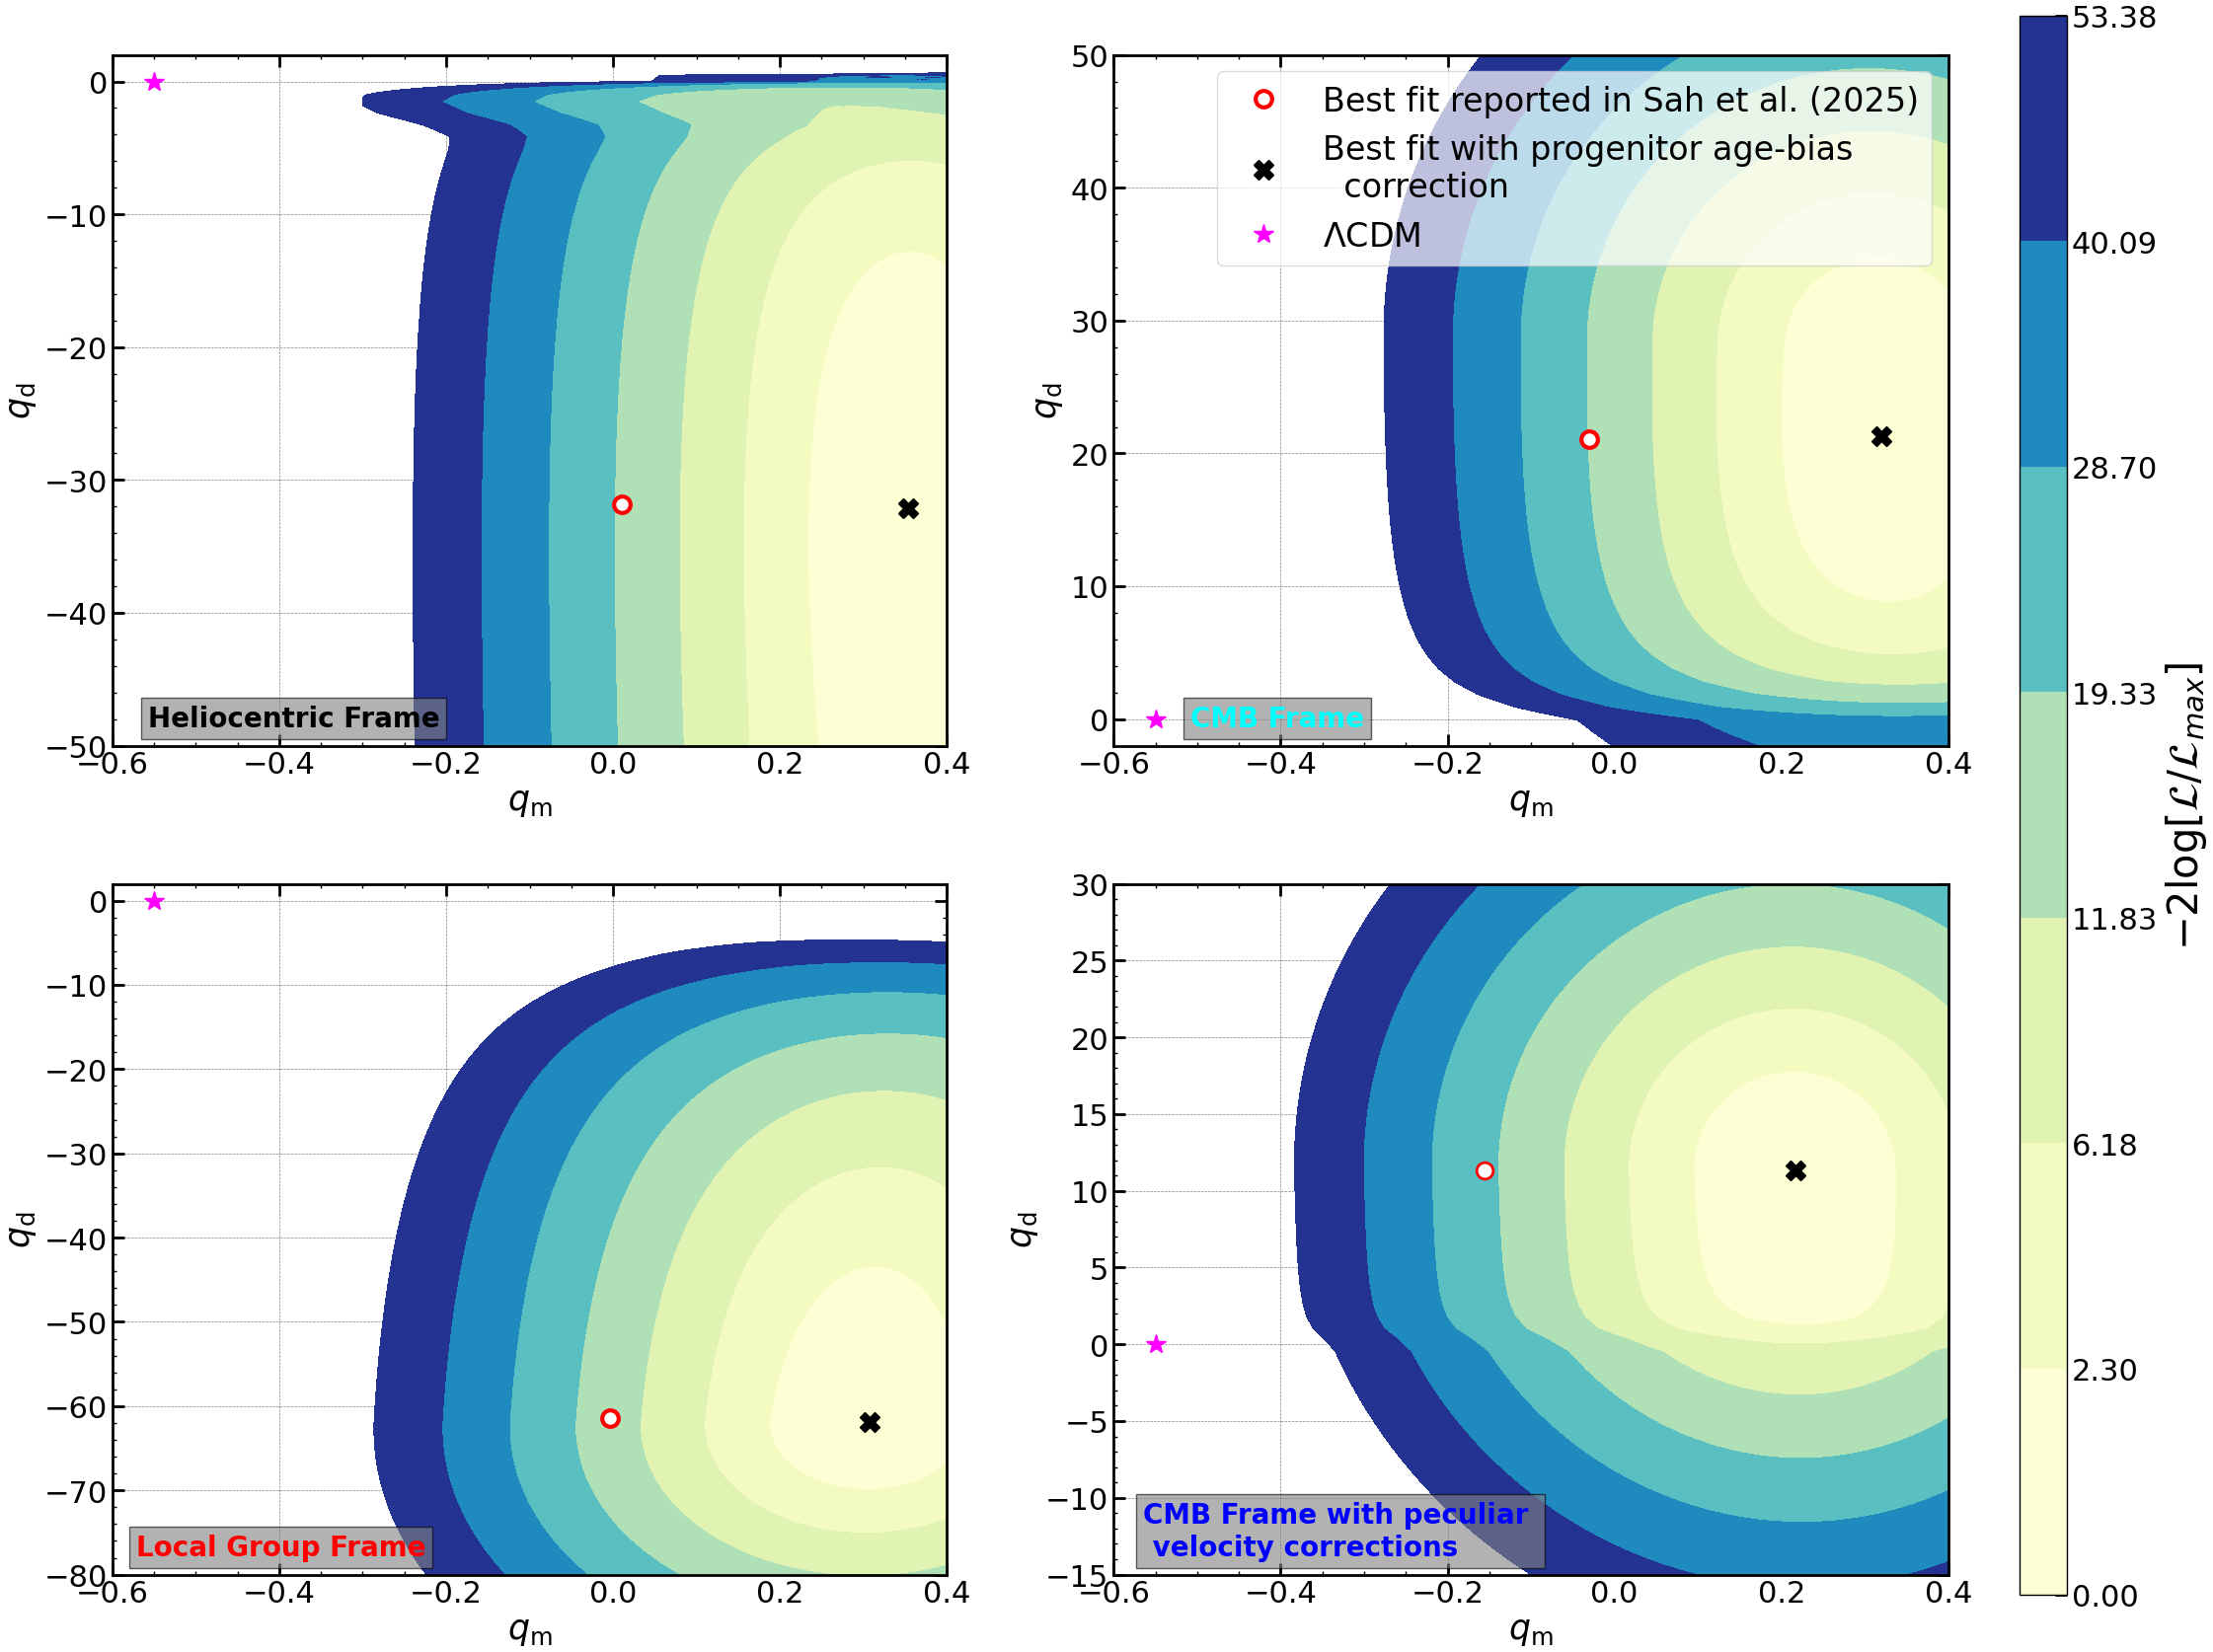

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(24,20))
ms = 12

levels = [0, 2.3, 6.18, 11.83, 19.33, 28.7,40.09,53.38]





# Extract data for C2 analysis
qm_hel_C2 = df_hel_C2[1].values
qd_hel_C2 = df_hel_C2[2].values
MLE_hel_C2 = df_hel_C2[3].values - np.min(df_hel_C2[3].values)

qm_CMB_C2 = df_cmb_C2[1].values
qd_CMB_C2 = df_cmb_C2[2].values
MLE_CMB_C2 = df_cmb_C2[3].values - np.min(df_cmb_C2[3].values)

qm_LG_C2 = df_lg_C2[1].values
qd_LG_C2 = df_lg_C2[2].values
MLE_LG_C2 = df_lg_C2[3].values - np.min(df_lg_C2[3].values)

qm_HD_C2  = df_HD_C2[1].values
qd_HD_C2  = df_HD_C2[2].values
MLE_HD_C2 = df_HD_C2[3].values - np.min(df_HD_C2[3].values)
# Plot C2 heliocentric frame
ax[0,0].tricontourf(qm_hel_C2, qd_hel_C2, MLE_hel_C2, 
                     levels=levels, cmap='YlGnBu')
ax[0,0].plot(qm_old_hel_C2, qd_old_hel_C2, 'ro',ms=ms,mfc='white',mew=3, label='Best fit reported in Sah et al. (2025)')
ax[0,0].plot(qm_new_hel_C2, qd_new_hel_C2, 'kX',ms=ms+2, label='Best fit with progenitor age-bias \n  correction')

# Plot C2 CMB frame
ax[0,1].tricontourf(qm_CMB_C2, qd_CMB_C2, MLE_CMB_C2, 
                     levels=levels, cmap='YlGnBu')
ax[0,1].plot(qm_old_cmb_C2, qd_old_cmb_C2, 'ro',ms=ms, mfc='white',mew=3, label='Best fit reported in Sah et al. (2025)')
ax[0,1].plot(qm_new_cmb_C2, qd_new_cmb_C2, 'kX',ms = ms+2, label='Best fit with progenitor age-bias \n  correction')

# Plot C2 Local Group frame
contour_plot= ax[1,0].tricontourf(qm_LG_C2, qd_LG_C2, MLE_LG_C2, 
                     levels=levels, cmap='YlGnBu')
ax[1,0].plot(qm_old_lg_C2, qd_old_lg_C2, 'ro',ms=ms,mfc='white',mew=3, label='Best fit reported in Sah et al. (2025)')
ax[1,0].plot(qm_new_lg_C2, qd_new_lg_C2, 'kX',ms=ms+2, label='Best fit with progenitor age-bias \n  correction')


ax[1,1].tricontourf(df_HD_C2[1].values, df_HD_C2[2].values, df_HD_C2[3].values - np.min(df_HD_C2[3].values), 
                     levels=levels, cmap='YlGnBu')



ax[1,1].plot(qm_old_HD_C2 , qd_old_HD_C2 , 'ro',ms=ms,mfc='white', mew=2,label='Best Fit reported in Sah et al. (2025)')
ax[1,1].plot(qm_new_HD_C2 , qd_new_HD_C2 , 'kX',ms=ms+2, label='Best fit with progenitor age-bias \n  correction')




for i in range(2):
    for j in range(2):
        ax[i,j].set_xlim(-0.6, 0.4)
        ax[i,j].set_xlabel('$q_\mathrm{m}$',fontsize=25)
        ax[i,j].set_ylabel('$q_\mathrm{d}$',fontsize=25)

for i in range(2):
    for j in range(2):
        ax[i,j].plot(-0.55, 0, '*',color='magenta', ms='15', label='$\Lambda$CDM')

ax[0,1].legend(frameon=True, framealpha=0.7,fontsize=24)

for i in range(0, 2):
    for j in range(0, 2):
        
            ax[i, j].set_ylim(ax[i, j].get_ylim())  # To ensure consistent axis limits
            ax[i, j].tick_params(labelsize=22, width=2, length=8.5, axis='both', which='major')
            for axis in ['left', 'bottom', 'top', 'right']:
                ax[i, j].spines[axis].set_linewidth(2)


fig.text(0.14,0.54,'Heliocentric Frame',size=20 ,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5,},weight='bold')
fig.text(0.58,0.54,'CMB Frame',size=20,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5},color='cyan',weight='bold')

fig.text(0.135,0.12,'Local Group Frame',size=20,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5},color='red',weight='bold')
fig.text(0.56,0.12,'CMB Frame with peculiar \n velocity corrections',size=20,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5},color='blue',weight='bold')
cax = fig.add_axes([0.93, 0.1, 0.02, 0.8])  # Adjust the position and size as needed
cbar = fig.colorbar(contour_plot, cax=cax)
cbar.set_label('$-2 \log [\mathcal{L}/\mathcal{L}_{max}]$', fontsize=30)
for axis in 'left', 'bottom','top','right':
           cbar.ax.spines[axis].set_linewidth(2)
cbar.ax.tick_params(labelsize=22,width=2,length=8.5,axis='both',which='major')
plt.savefig('Age_bias_corrected_contours_C2.pdf')
plt.show()



/tmp/ipykernel_27446/2491227395.py:80: UserWarning: Adding colorbar to a different Figure <Figure size 2400x2000 with 5 Axes> than <Figure size 2400x2000 with 5 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(contour_plot, cax=cax)


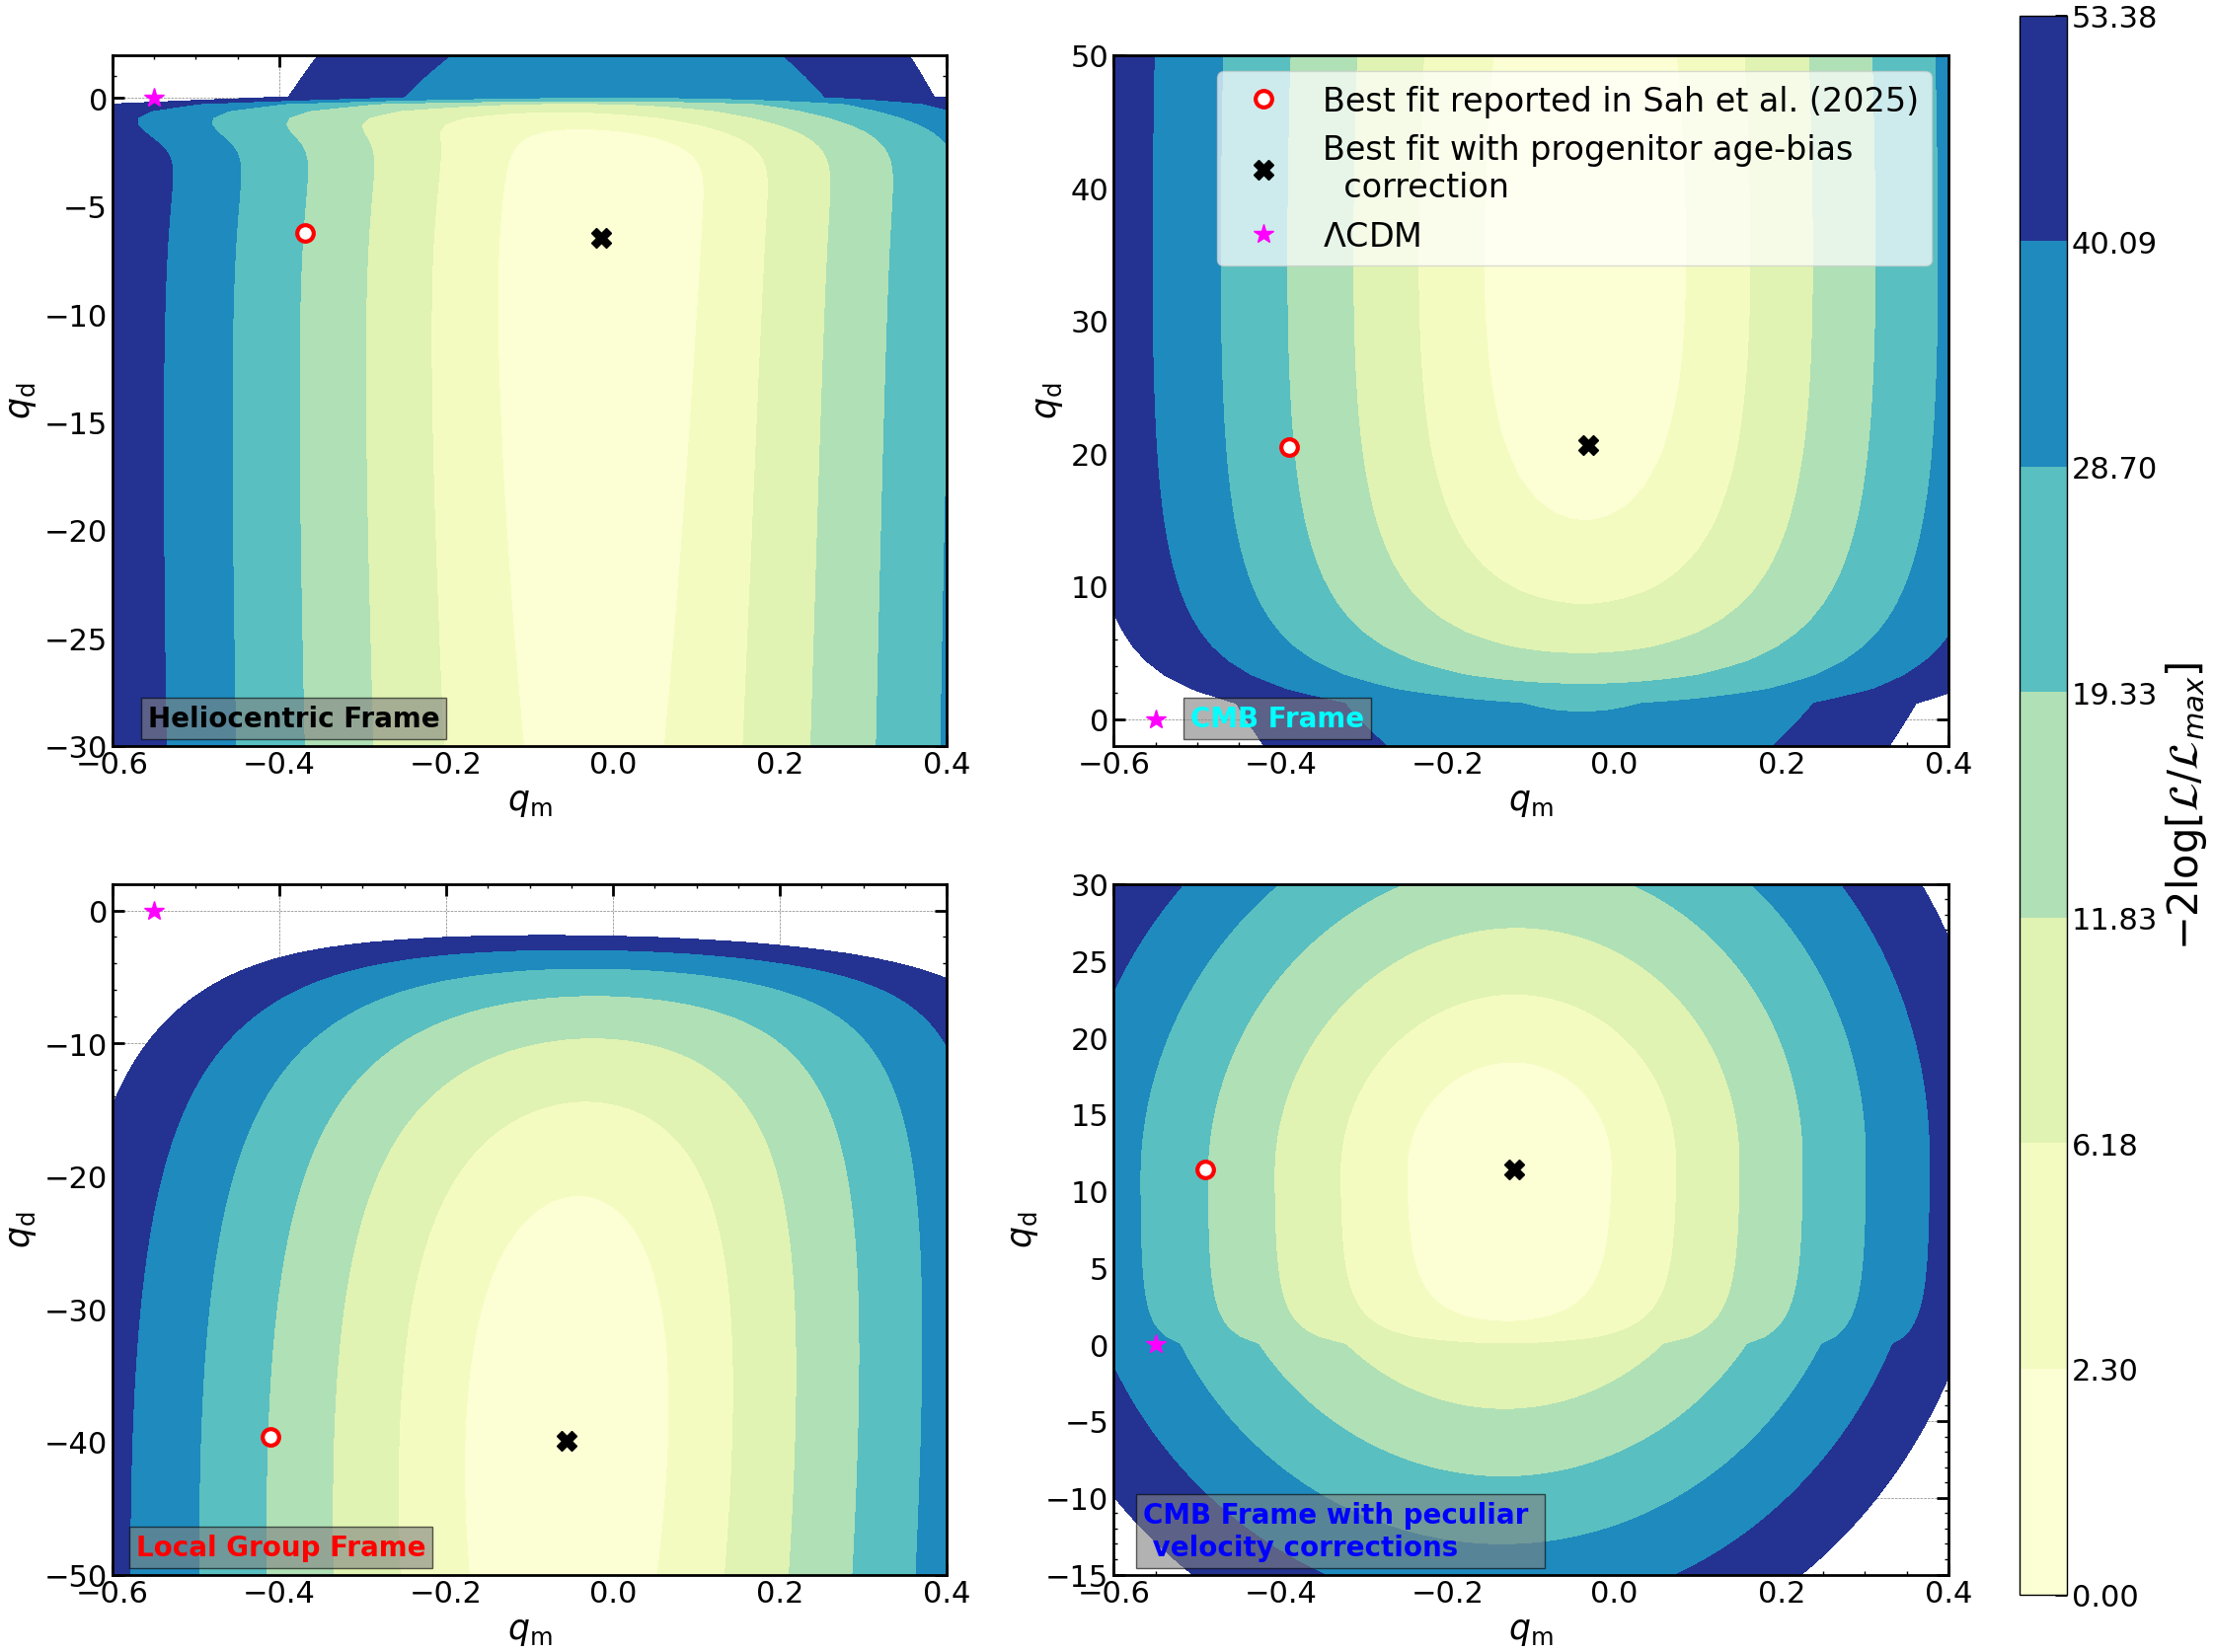

In [30]:
fig, ax = plt.subplots(2, 2, figsize=(24,20))
ms = 12

levels = [0, 2.3, 6.18, 11.83, 19.33, 28.7,40.09,53.38]
##plotting for analysis C1
contour_maker(grid_maker(qm_hel_C1, qd_hel_C1), MLE_hel_C1,ax=ax[0,0],levels=levels)
contour_maker(grid_maker(qm_CMB_C1, qd_CMB_C1), MLE_CMB_C1,ax=ax[0,1],levels=levels)
contour_maker(grid_maker(qm_LG_C1, qd_LG_C1,bool_term =True,true_indices=LG_indices_C1), MLE_LG_C1[0], bool_term=True,ax=ax[1,0],levels=levels)
contour_maker(grid_maker(qm_HD_C1, qd_HD_C1), MLE_HD_C1,ax=ax[1,1],levels=levels)
ax[0,0].plot(qm_previous_hel_C1, qd_previous_hel_C1, 'ro',ms=ms, mfc='white',mew=3, label='Best fit reported in Sah et al. (2025)')
ax[0,0].plot(qm_new_hel_C1, qd_new_hel_C1, 'kX',ms=ms+2, label='Best fit with progenitor age-bias \n  correction')

ax[0,1].plot(qm_previous_CMB_C1, qd_previous_CMB_C1, 'ro', ms=ms, mfc='white',mew=3, label='Best fit reported in Sah et al. (2025)')
ax[0,1].plot(qm_new_CMB_C1, qd_new_CMB_C1, 'kX', ms=ms+2, label='Best fit with progenitor age-bias \n  correction')

ax[1,0].plot(qm_previous_LG_C1, qd_previous_LG_C1, 'ro', ms=ms, mfc='white',mew=3, label='Best fit reported in Sah et al. (2025)')
ax[1,0].plot(qm_new_LG_C1, qd_new_LG_C1, 'kX', ms=ms+2, label='Best fit with progenitor age-bias \n  correction')
ax[1,1].plot(qm_previous_HD_C1, qd_previous_HD_C1, 'ro', ms=ms, mfc='white',mew=3, label='Best fit reported in Sah et al. (2025)')
ax[1,1].plot(qm_new_HD_C1, qd_new_HD_C1, 'kX', ms=ms+2, label='Best fit with progenitor age-bias \n  correction')
##plotting for analysis C2




# Extract data for C2 analysis
qm_hel_C2 = df_hel_C2[1].values
qd_hel_C2 = df_hel_C2[2].values
MLE_hel_C2 = df_hel_C2[3].values - np.min(df_hel_C2[3].values)

qm_CMB_C2 = df_cmb_C2[1].values
qd_CMB_C2 = df_cmb_C2[2].values
MLE_CMB_C2 = df_cmb_C2[3].values - np.min(df_cmb_C2[3].values)

qm_LG_C2 = df_lg_C2[1].values
qd_LG_C2 = df_lg_C2[2].values
MLE_LG_C2 = df_lg_C2[3].values - np.min(df_lg_C2[3].values)

# Plot C2 heliocentric frame






for i in range(2):
    for j in range(2):
        ax[i,j].set_xlim(-0.6, 0.4)
        ax[i,j].set_xlabel('$q_\mathrm{m}$',fontsize=25)
        ax[i,j].set_ylabel('$q_\mathrm{d}$',fontsize=25)

for i in range(2):
    for j in range(2):
        ax[i,j].plot(-0.55, 0, '*',color='magenta', ms='15', label='$\Lambda$CDM')

ax[0,1].legend(frameon=True, framealpha=0.7,fontsize=24 )

for i in range(0,2 ):
    for j in range(0, 2):
        
            ax[i, j].set_ylim(ax[i, j].get_ylim())  # To ensure consistent axis limits
            ax[i, j].tick_params(labelsize=22, width=2, length=8.5, axis='both', which='major')
            for axis in ['left', 'bottom', 'top', 'right']:
                ax[i, j].spines[axis].set_linewidth(2)
# fig.text(0.386,0.39,'CMB Frame',size=20,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5},color='cyan',weight='bold')
# fig.text(0.805,0.39,'CMB Frame',size=20,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5},color='cyan',weight='bold')

# fig.text(0.33,0.66,'Heliocentric Frame',size=20 ,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5,},weight='bold')
# fig.text(0.755,0.66,'Heliocentric Frame',size=20,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5,},weight='bold')

# fig.text(0.34,0.12,'Local Group Frame',size=20,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5},color='red',weight='bold')
# fig.text(0.756,0.12,'Local Group Frame',size=20,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5},color='red',weight='bold')

fig.text(0.14,0.54,'Heliocentric Frame',size=20 ,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5,},weight='bold')
fig.text(0.58,0.54,'CMB Frame',size=20,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5},color='cyan',weight='bold')

fig.text(0.135,0.12,'Local Group Frame',size=20,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5},color='red',weight='bold')
fig.text(0.56,0.12,'CMB Frame with peculiar \n velocity corrections',size=20,bbox={'facecolor': 'gray','alpha': 0.6, 'pad': 5},color='blue',weight='bold')

cax = fig.add_axes([0.93, 0.1, 0.02, 0.8])  # Adjust the position and size as needed
cbar = fig.colorbar(contour_plot, cax=cax)
cbar.set_label('$-2 \log [\mathcal{L}/\mathcal{L}_{max}]$', fontsize=30)
for axis in 'left', 'bottom','top','right':
           cbar.ax.spines[axis].set_linewidth(2)
cbar.ax.tick_params(labelsize=22,width=2,length=8.5,axis='both',which='major')
plt.savefig('Age_bias_corrected_conoturs.pdf')
plt.show()

